### Descriptive statistics
#### - Histogram
#### - Boxplot

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
plt.style.use('ggplot')

In [3]:
# a dataset of 30 items, digits from 0 to 14
x = [1, 2, 3, 1, 12, 11, 11, 13, 2, 2,
     1, 2, 3, 2, 13, 14, 12, 9, 9, 0,
     1, 2, 3, 4, 13, 6, 12, 8, 0, 0]

In [8]:
# chacking what data we have in our dataset - not an informative way
pd.Series(x).value_counts().sort_index()

0     3
1     4
2     6
3     3
4     1
6     1
8     1
9     2
11    2
12    3
13    3
14    1
Name: count, dtype: int64

<Axes: >

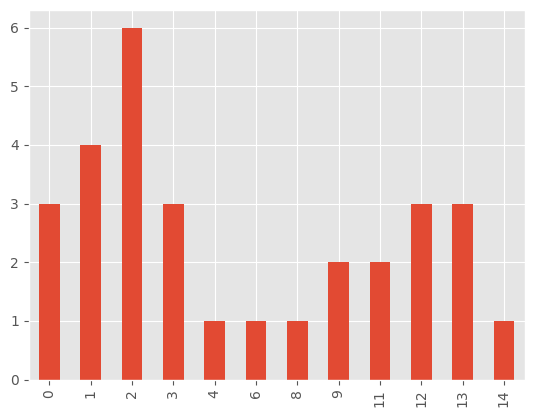

In [10]:
# a better way - but only works for a small dataset
pd.Series(x).value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='Frequency'>

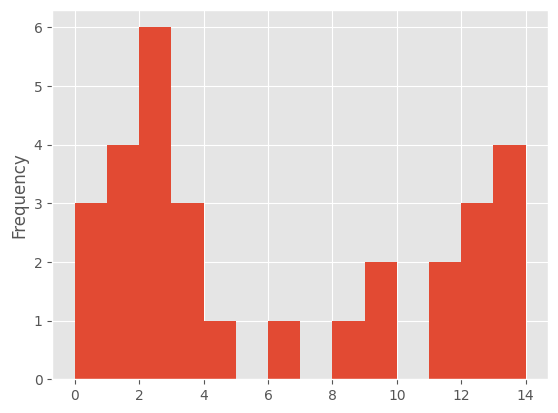

In [13]:
# an easier way - plot histogram, use bins=X to divide data in X chunks
pd.Series(x).plot(kind='hist', bins=14)

In [14]:
data_df = pd.read_csv('../01_general_python_numpy_pandas/data/covid-19-us-counties.csv')
data_df.head()

,date,county,state,fips,cases,deaths
0,2020-01-21,Snohomish,Washington,53061.0,1,0.0
1,2020-01-22,Snohomish,Washington,53061.0,1,0.0
2,2020-01-23,Snohomish,Washington,53061.0,1,0.0
3,2020-01-24,Cook,Illinois,17031.0,1,0.0
4,2020-01-24,Snohomish,Washington,53061.0,1,0.0


In [16]:
# calculate how many covid cases we had in each county, mean
cases_by_county = data_df.groupby('county')['cases'].mean()

In [17]:
cases_by_county.head()

county
Abbeville     378.666667
Acadia       1952.018315
Accomack      930.934545
Ada          9164.478723
Adair         302.481001
Name: cases, dtype: float64

In [18]:
cases_by_county.shape

(1930,)

array([<Axes: title={'center': 'cases'}>], dtype=object)

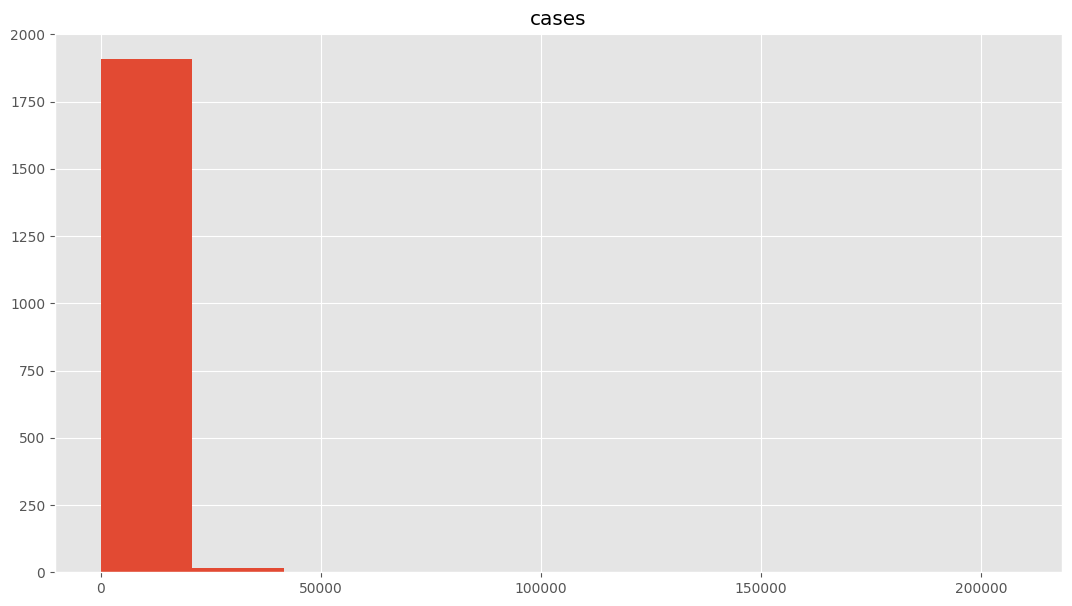

In [19]:
# let us display our data
fig, axes = plt.subplots(1, figsize=(13, 7))

pd.DataFrame(cases_by_county).hist(ax=axes)

(0.0, 1500.0)

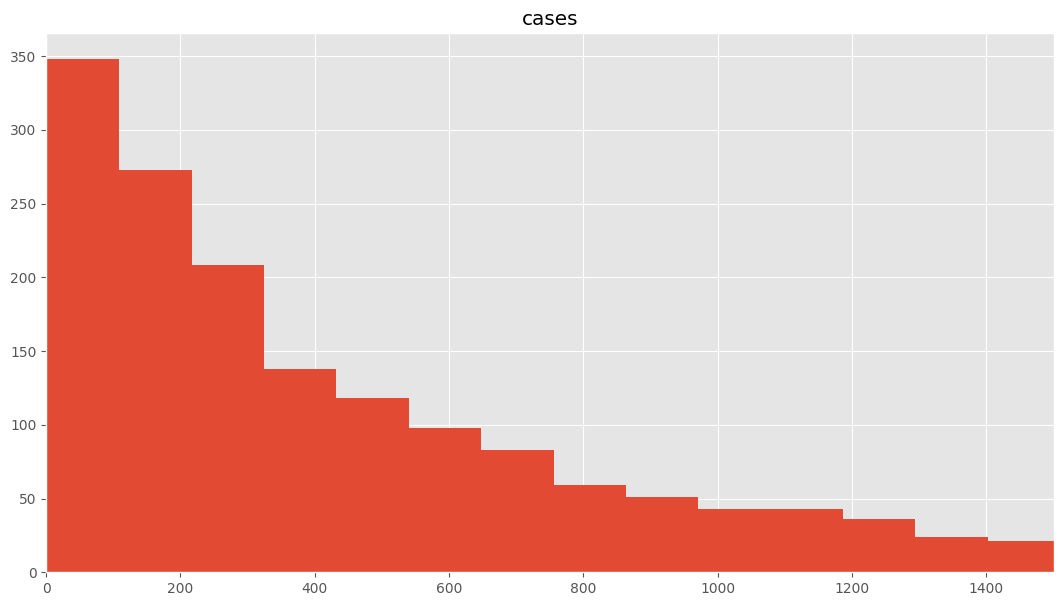

In [22]:
# to make it more informative, let's limit X axis and configure bins='number of unique values'
fig, axes = plt.subplots(1, figsize=(13, 7))

pd.DataFrame(cases_by_county).hist(ax=axes, bins=1930)

axes.set_xlim((0, 1500))


In [23]:
# let's analyse housing prices
housing_prices_df = pd.read_csv('data/housing_price.csv')
housing_prices_df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,Zona-Agea A,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,Zona-Agea B,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,Zona-Agea A,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,Zona-Agea A,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,Zona-Agea A,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


<Axes: >

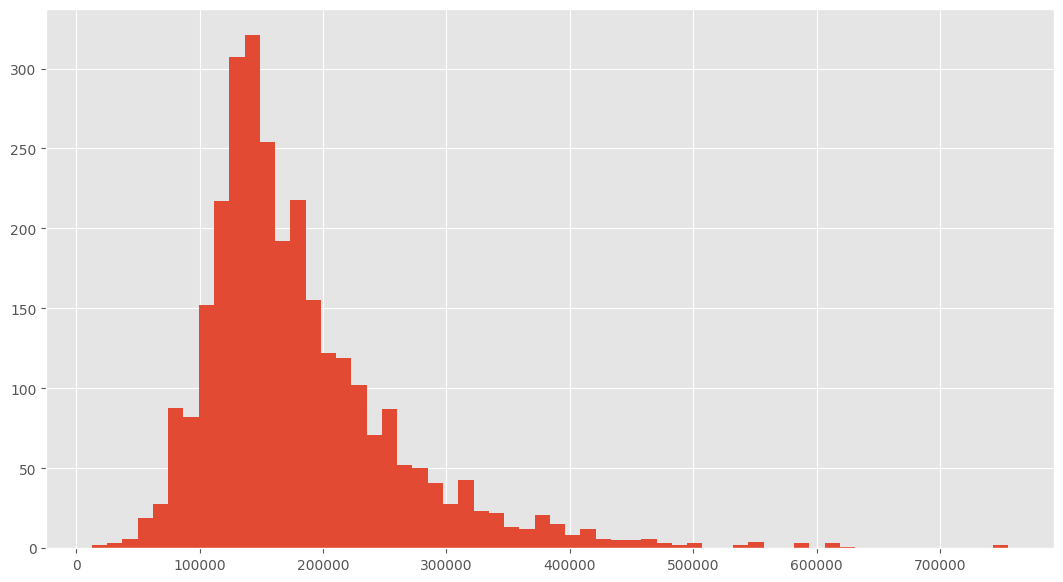

In [26]:
# bins=X indicates how many vertical bars we'll have, so histogram will more smoothly go around our data
housing_prices_df['SalePrice'].hist(figsize=(13, 7), bins=60)

<Axes: >

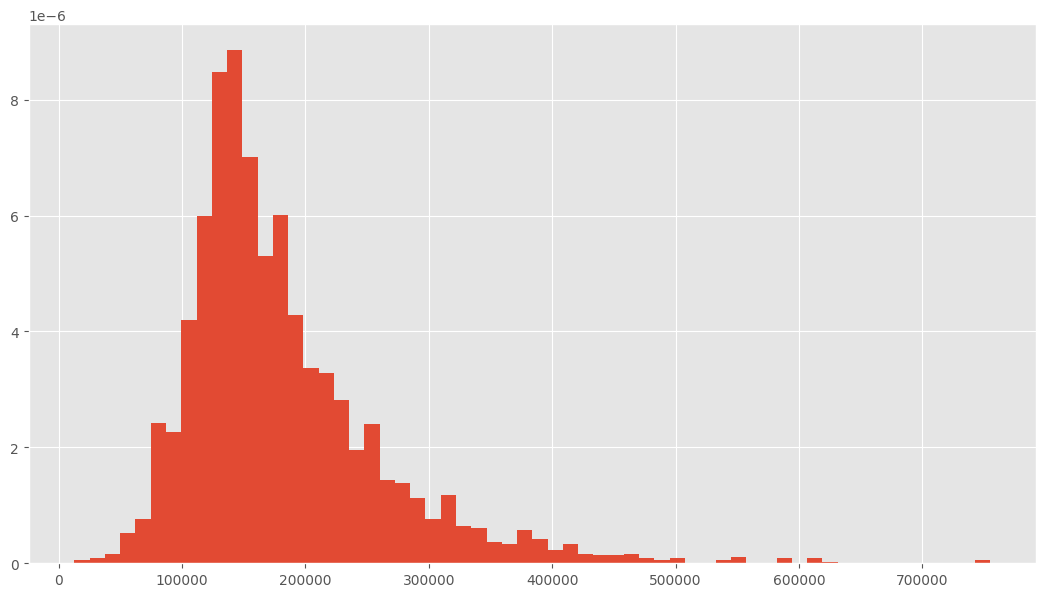

In [28]:
# density param will show %%, basically equalling the whole painted red area to one, and showing %% of it on Y axis
# we can intepret it as "What is the probability that a house price will be in range X1 - X2? Answer: Y axis!"
housing_prices_df['SalePrice'].hist(figsize=(13, 7), bins=60, density=True)

In [29]:
# checking main stats for a selected field with .describe field
housing_prices_df['SalePrice'].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

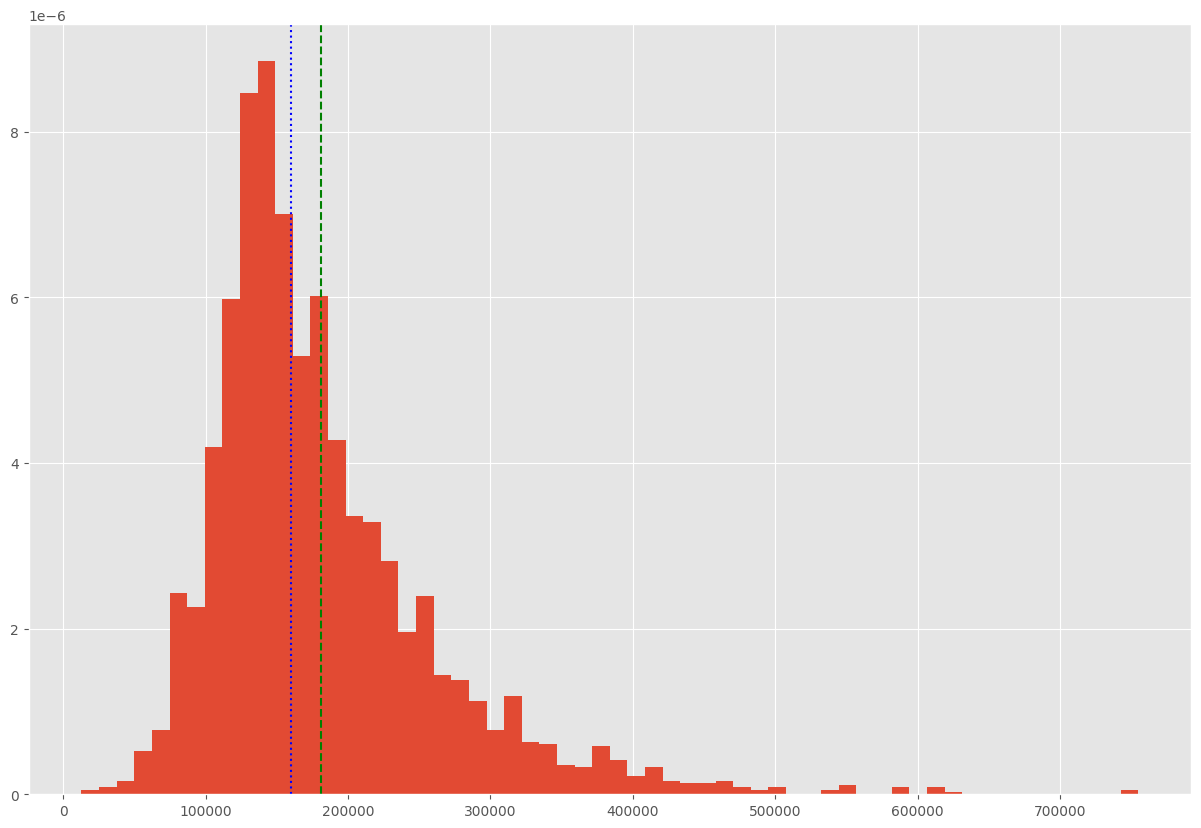

In [30]:
# let's add mean and 50% to the plot
fig, axes = plt.subplots(1, figsize=(14, 7))

housing_prices_df['SalePrice'].hist(figsize=(15, 10), bins=60, density=True, ax=axes)

axes.axvline(180796.060068, ls='--', color='g')
axes.axvline(160000.000000, ls=':', color='b')

### histograms in Seaborn

In [31]:
import seaborn as sns

<Axes: xlabel='SalePrice', ylabel='Count'>

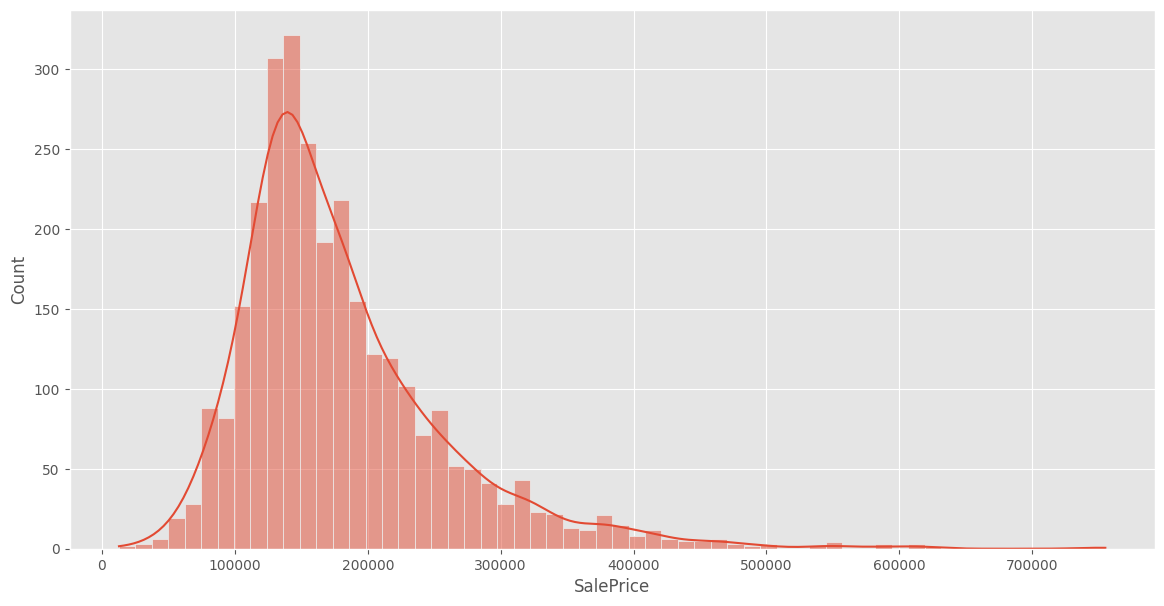

In [34]:
fig, axes = plt.subplots(1, figsize=(14, 7))
sns.histplot(housing_prices_df, x='SalePrice', bins=60, ax=axes, kde=True)

In [35]:
# ok, now we'll explore one of the most descriptive cases, answering why we really need histograms and what we can do
# with this analysis. Swiss banknotes case.
sw_bank_df = pd.read_csv('data/swiss_bank_notes.csv')
sw_bank_df.head()

,Status,Length,Left,Right,Bottom,Top,Diagonal
0,fake,214.4,130.1,130.3,9.7,11.7,139.8
1,fake,214.9,130.5,130.2,11.0,11.5,139.5
2,fake,214.9,130.3,130.1,8.7,11.7,140.2
3,fake,215.0,130.4,130.6,9.9,10.9,140.3
4,fake,214.7,130.2,130.3,11.8,10.9,139.7


In [36]:
# how many fake and original banknotes we have
sw_bank_df['Status'].value_counts()

Status
fake        100
original    100
Name: count, dtype: int64

<Axes: xlabel='Length', ylabel='Count'>

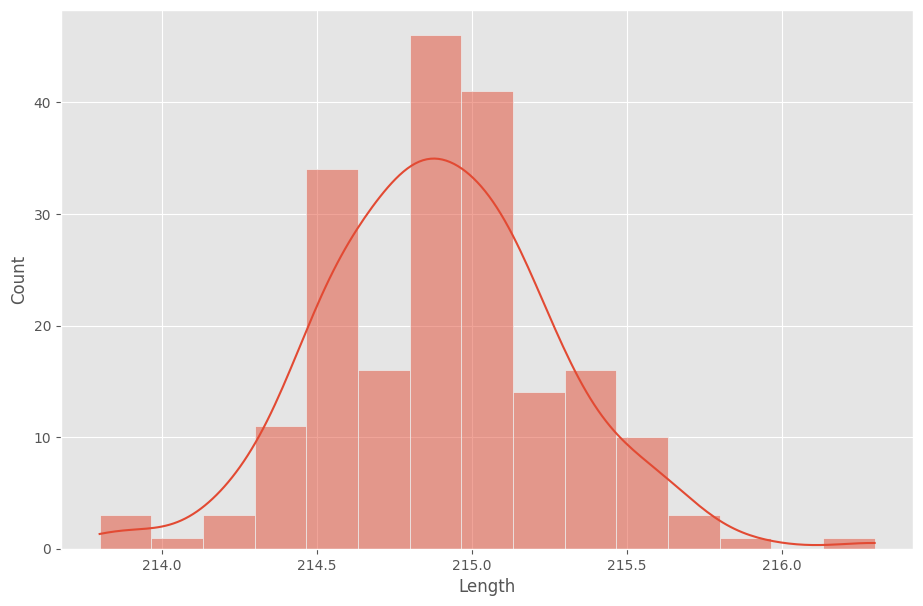

In [38]:
# let's check distribution by Length
fig, axes = plt.subplots(1, figsize=(11, 7))
sns.histplot(sw_bank_df, x='Length', ax=axes, kde=True)

<Axes: xlabel='Length', ylabel='Count'>

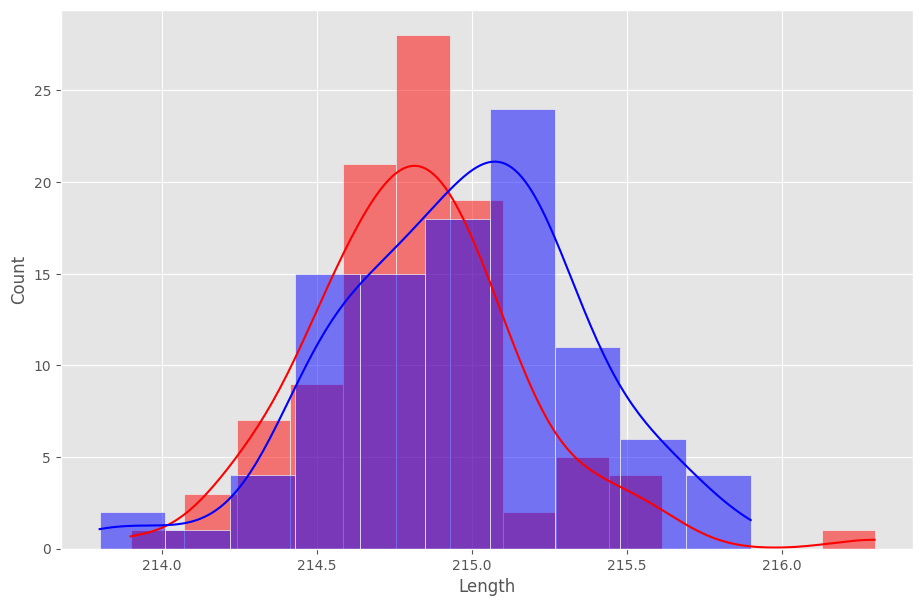

In [39]:
# to make it more informative, let's build for fake and original banknotes
fig, axes = plt.subplots(1, figsize=(11, 7))
sns.histplot(sw_bank_df[sw_bank_df['Status'] == 'fake'], x='Length', ax=axes, kde=True, color='r')
sns.histplot(sw_bank_df[sw_bank_df['Status'] == 'original'], x='Length', ax=axes, kde=True, color='b')

In [ ]:
# there's clearly a difference, but it's hard to say how big it is - we need to further explore statistical importance

In [40]:
# now we can use scatter_matrix to get a better picture of data distribution for all metrics
from pandas.plotting import scatter_matrix

/var/folders/4s/q7yddbmx5x5cv8bjf0127cvr0000gn/T/ipykernel_3141/3725077522.py:2: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  scatter_matrix(sw_bank_df, diagonal='kde', ax=axes)


array([[<Axes: xlabel='Length', ylabel='Length'>,
        <Axes: xlabel='Left', ylabel='Length'>,
        <Axes: xlabel='Right', ylabel='Length'>,
        <Axes: xlabel='Bottom', ylabel='Length'>,
        <Axes: xlabel='Top', ylabel='Length'>,
        <Axes: xlabel='Diagonal', ylabel='Length'>],
       [<Axes: xlabel='Length', ylabel='Left'>,
        <Axes: xlabel='Left', ylabel='Left'>,
        <Axes: xlabel='Right', ylabel='Left'>,
        <Axes: xlabel='Bottom', ylabel='Left'>,
        <Axes: xlabel='Top', ylabel='Left'>,
        <Axes: xlabel='Diagonal', ylabel='Left'>],
       [<Axes: xlabel='Length', ylabel='Right'>,
        <Axes: xlabel='Left', ylabel='Right'>,
        <Axes: xlabel='Right', ylabel='Right'>,
        <Axes: xlabel='Bottom', ylabel='Right'>,
        <Axes: xlabel='Top', ylabel='Right'>,
        <Axes: xlabel='Diagonal', ylabel='Right'>],
       [<Axes: xlabel='Length', ylabel='Bottom'>,
        <Axes: xlabel='Left', ylabel='Bottom'>,
        <Axes: xlabel='Right'

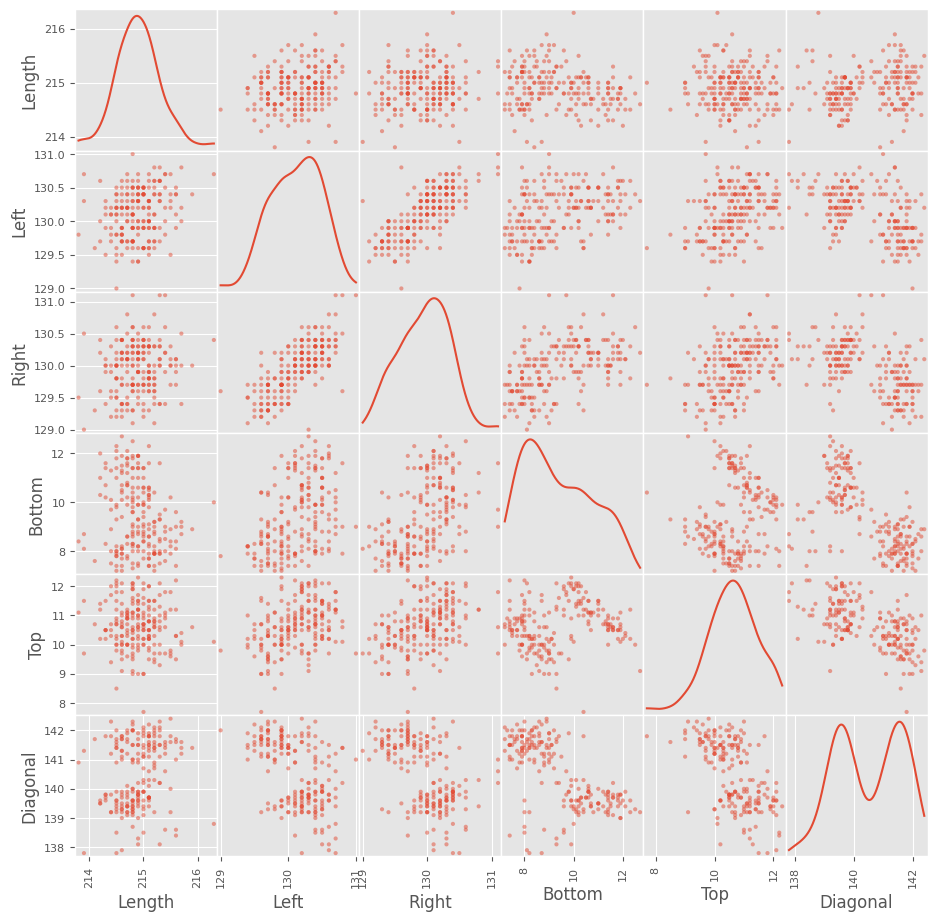

In [42]:
fig, axes = plt.subplots(1, 1, figsize=(11, 11))
scatter_matrix(sw_bank_df, diagonal='kde', ax=axes)

/var/folders/4s/q7yddbmx5x5cv8bjf0127cvr0000gn/T/ipykernel_3141/432532694.py:4: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  scatter_matrix(sw_bank_df,


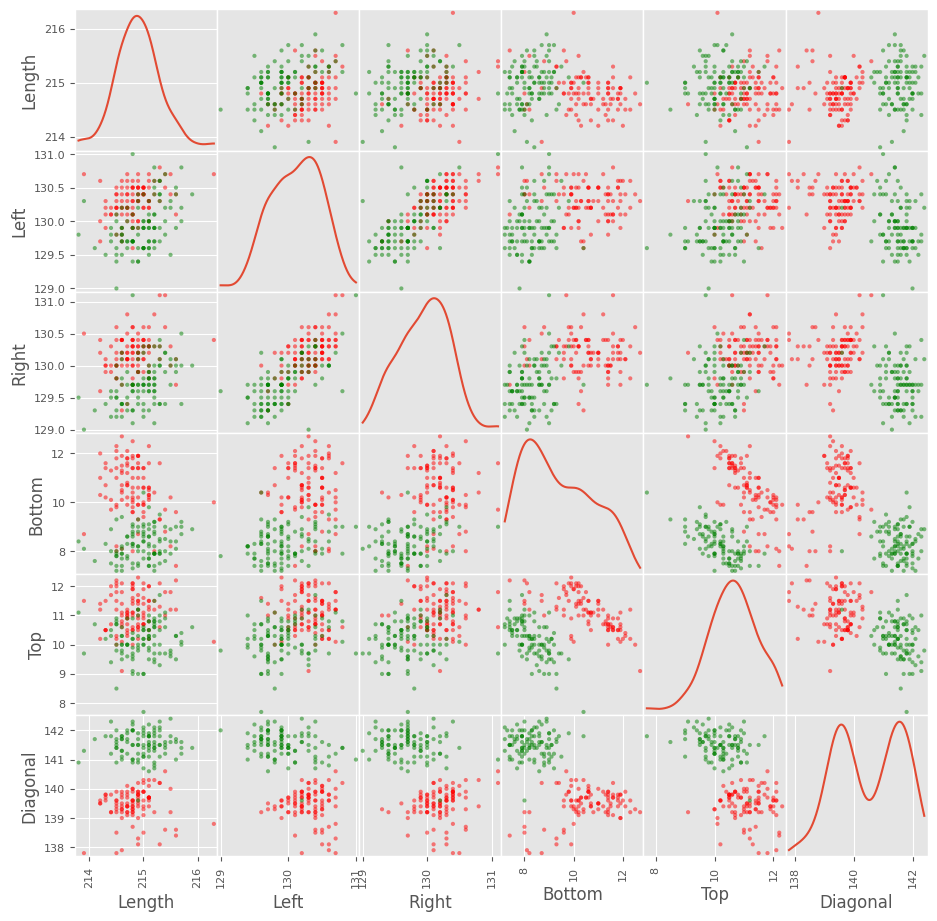

In [43]:
# we can clearly bimodality in Diagonal's distribution, so let's explore it in more details for fake & original
fig, axes = plt.subplots(1, 1, figsize=(11, 11))

scatter_matrix(sw_bank_df,
               diagonal='kde',
               c=sw_bank_df['Status'].replace({'original': 'green', 'fake': 'red'}),
               ax=axes
              );

In [ ]:
# we can clearly see that data for fake and original banknotes is in 2 separate groups for Diagonal param
# and bimodality for Diagonal can be explained by this

<Axes: xlabel='Diagonal', ylabel='Count'>

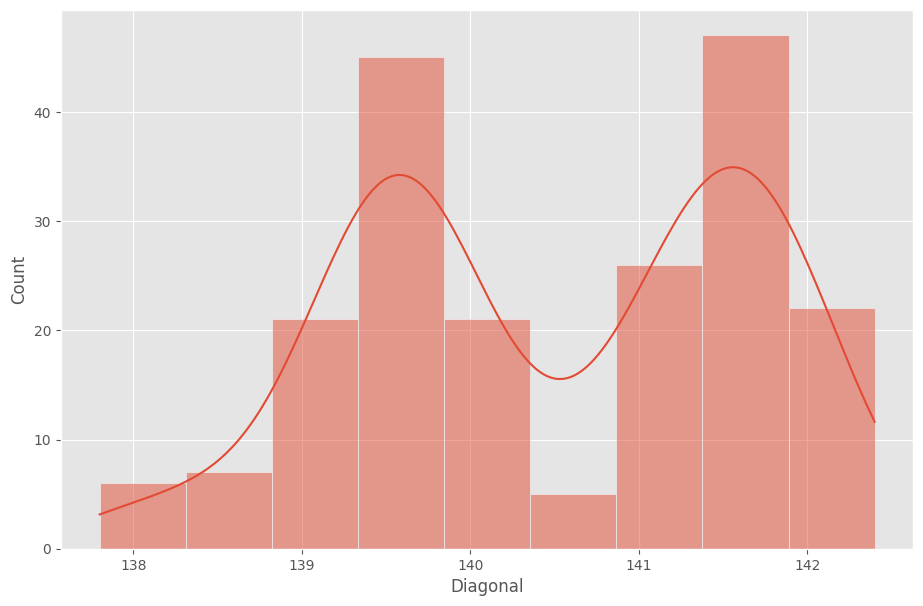

In [44]:
fig, axes = plt.subplots(1, figsize=(11, 7))
sns.histplot(sw_bank_df, x='Diagonal', ax=axes, kde=True)

<Axes: xlabel='Diagonal', ylabel='Count'>

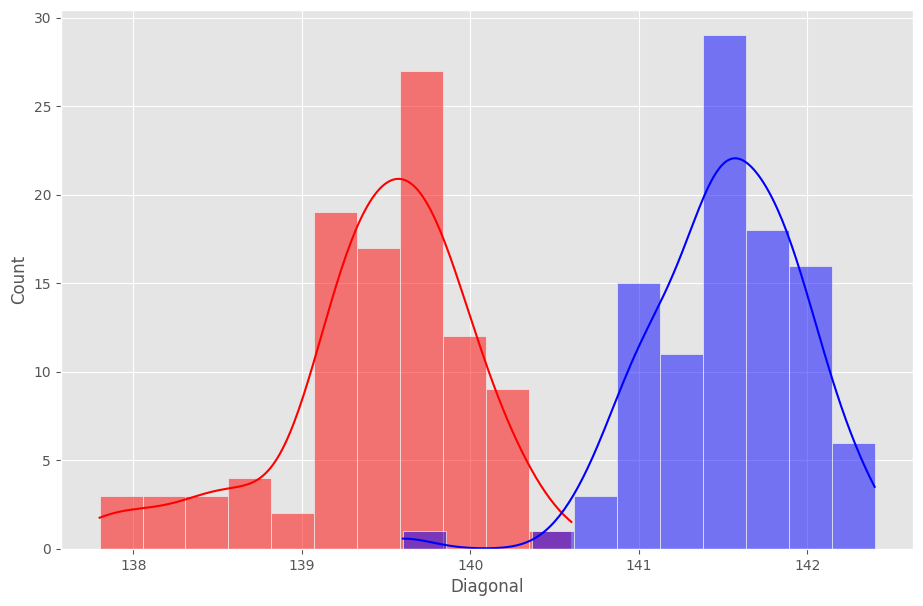

In [45]:
fig, axes = plt.subplots(1, figsize=(11, 7))

sns.histplot(sw_bank_df[sw_bank_df['Status']=='fake'], x="Diagonal", ax=axes, kde=True, color='r')

sns.histplot(sw_bank_df[sw_bank_df['Status']=='original'], x="Diagonal", ax=axes, kde=True, color='b')

In [ ]:
# so we can simply measure each banknotes by diagonal, ignoring all other params.
# if diagonal is > 140.5, then it's an original banknote with a very high probability
# but there's some amount of originals with small diagonal

<Axes: xlabel='Diagonal', ylabel='Top'>

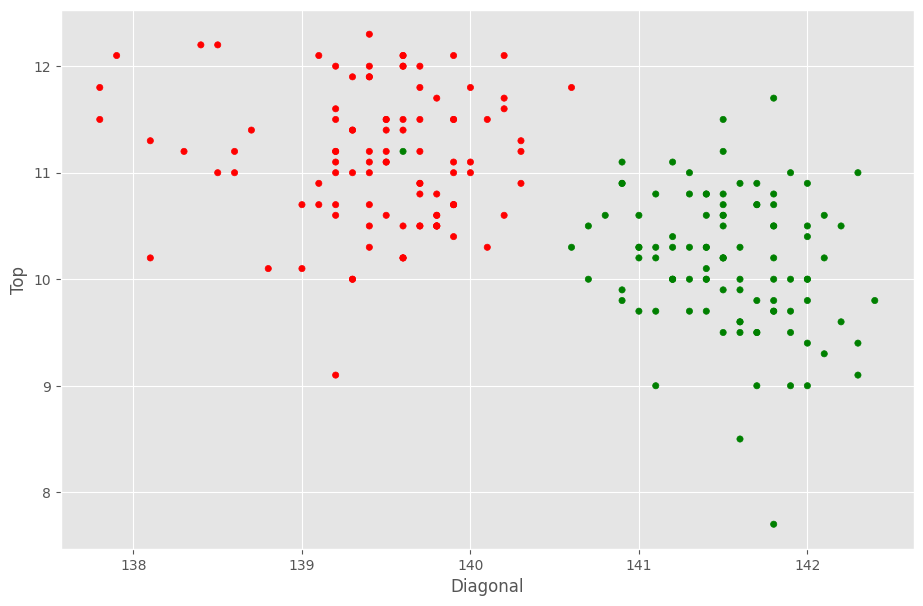

In [46]:
# we can draw our inspection line not by 90 degrees to Diagonal, but adjust it a bit, taking into account Top param.
# This will increase precision of our model.
fig, axes = plt.subplots(1, figsize=(11, 7))

sw_bank_df.plot.scatter(x='Diagonal', 
                y='Top', 
                c=sw_bank_df['Status'].replace({'original': 'green', 'fake': 'red'}), 
                ax=axes)

In [ ]:
# as a result, we can build a classifier model, using correct input params - Diagonal & Top

<Axes: xlabel='Diagonal', ylabel='Top'>

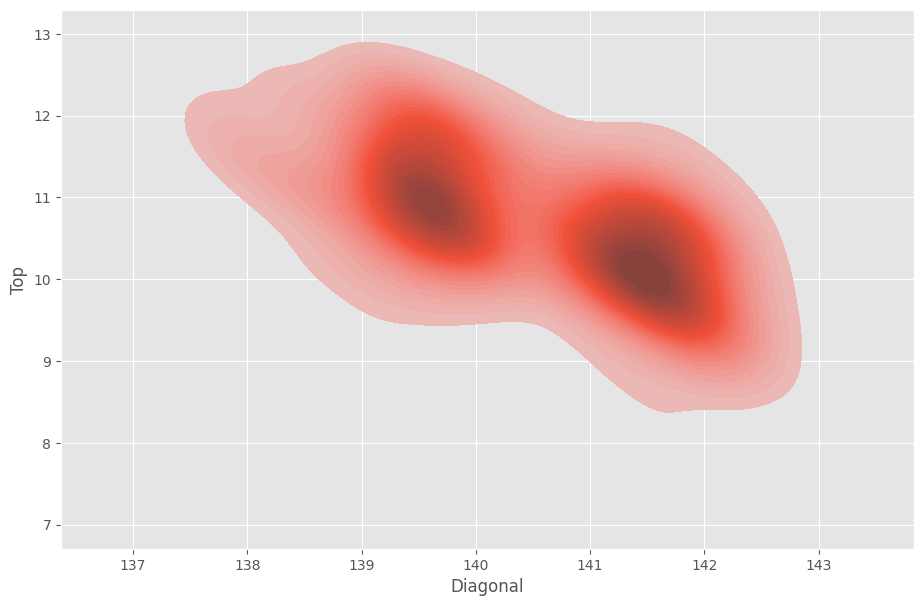

In [48]:
# using a similar instrument from Seaborn
fig, axes = plt.subplots(1, figsize=(11, 7))

sns.kdeplot(data=sw_bank_df, x='Diagonal', y='Top', ax=axes, levels=30, fill=True)

<Axes: xlabel='Diagonal', ylabel='Top'>

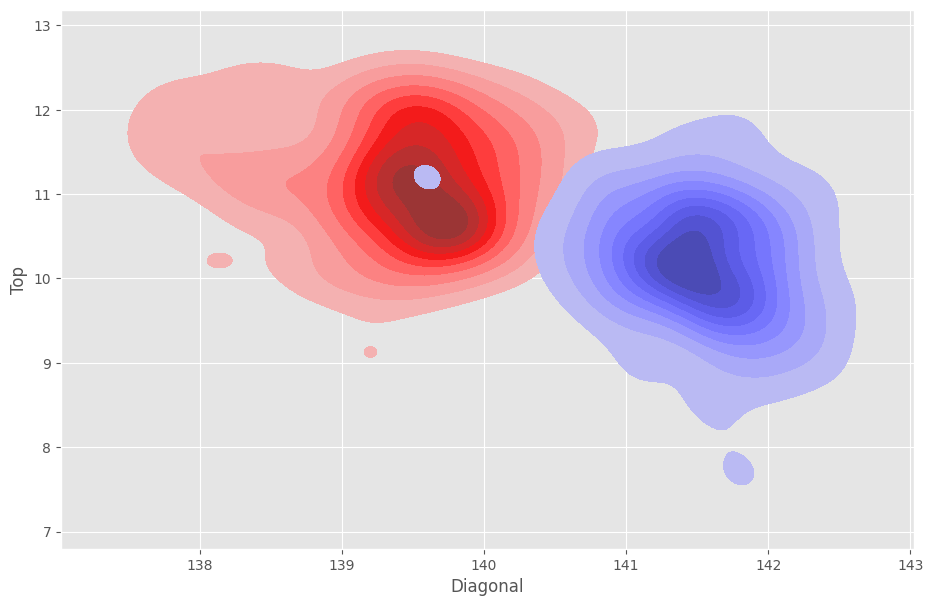

In [49]:
fig, axes = plt.subplots(1, figsize=(11, 7))

sns.kdeplot(data=sw_bank_df[sw_bank_df['Status']=='fake'], x='Diagonal', y='Top', ax=axes, fill=True, color='r')
sns.kdeplot(data=sw_bank_df[sw_bank_df['Status']=='original'], x='Diagonal', y='Top', ax=axes, fill=True, color='b')

In [ ]:
# scatterplot shows the same, and usually it's enough to use just it

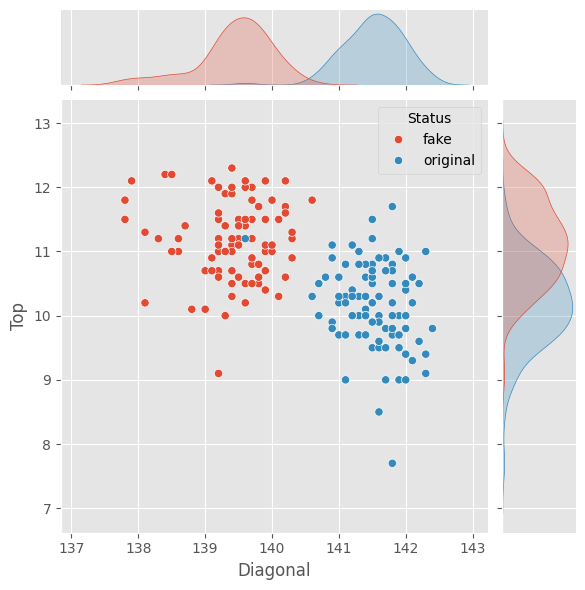

In [50]:
# a combined plot - distribution & scatter plot in one flask
sns.jointplot(data=sw_bank_df,
              x="Diagonal", 
              y="Top", 
              hue="Status"
)

### If we have more than 2 params, better use not histogram but other tool - Boxplots

In [51]:
housing_prices_df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,Zona-Agea A,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,Zona-Agea B,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,Zona-Agea A,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,Zona-Agea A,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,Zona-Agea A,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [56]:
housing_prices_df['MS Zoning'].unique()

array(['Zona-Agea A', 'Zona-Agea B', 'Zona-Agea C', 'Zona-Agea D',
       'Zona-Agea E', 'Zona-Agea F', 'Zona-Agea H'], dtype=object)

In [53]:
housing_prices_df['MS Zoning'].unique().size

7

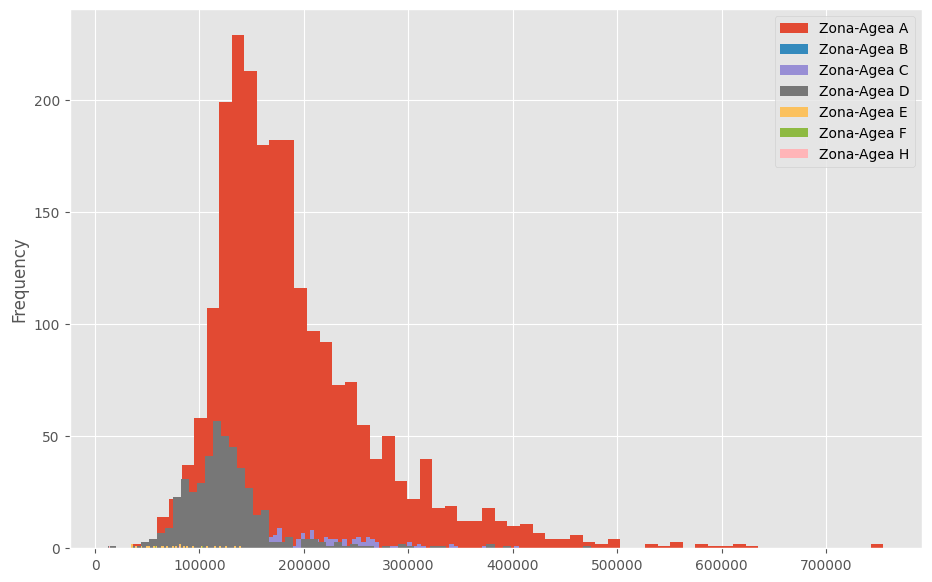

In [ ]:
# we can see that some zones are dominant, A and D
fig, axes = plt.subplots(1, figsize=(11, 7))
housing_prices_df.groupby('MS Zoning')['SalePrice'].plot.hist(bins=60)
axes.legend()

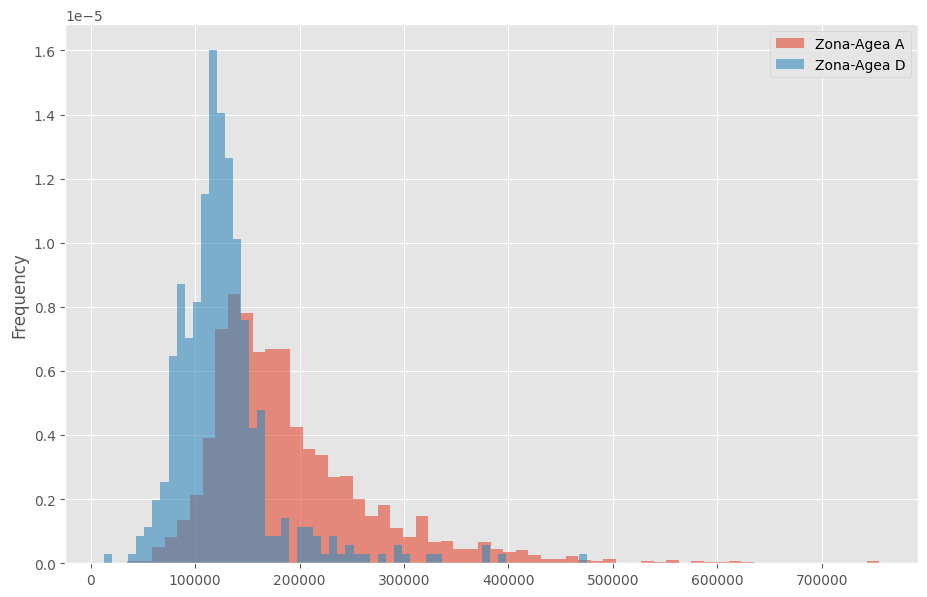

In [60]:
# exploring dominant zones in detail
fig, axes = plt.subplots(1, figsize=(11, 7))

data_2_z = housing_prices_df[housing_prices_df['MS Zoning'].isin(['Zona-Agea A', 'Zona-Agea D'])]

data_2_z.groupby('MS Zoning')['SalePrice'].plot.hist(bins=60, density=True, alpha=0.6)

axes.legend();

In [ ]:
# we see that there are more observations in Zone A than in D, that's why the height is different
# but mean is pretty similar
# using density=True allows us to make A & D closer, as area under distrib graph will be equal to 1

<Axes: title={'center': 'SalePrice'}, xlabel='MS Zoning'>

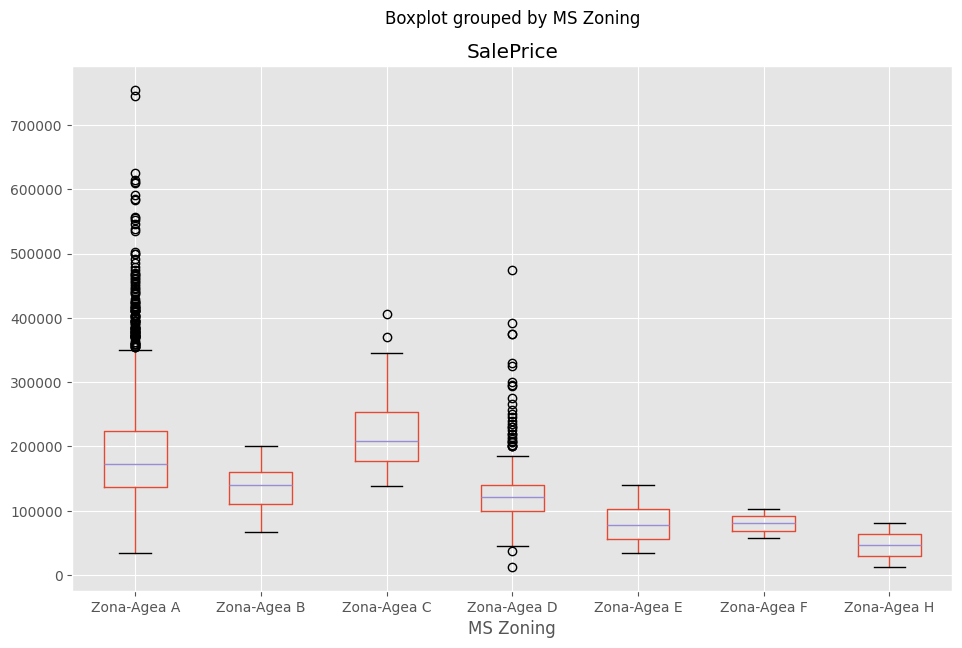

In [61]:
# but we have more than 2 zones, so better to use Boxplots to find out what is the relation b/w them
fig, axes = plt.subplots(1, 1, figsize=(11, 7))
housing_prices_df.boxplot(column='SalePrice', by='MS Zoning', ax=axes)

In [ ]:
# to build a boxplot, we sort our data, put 50% of data (b/w 25th and 75th percentile, IQR) into boxplot
# show meadian, 1.5 IQR are depicted as a mustache line, all other data are outliers